# EDA

What it does:
  1. Loads your dataset (CSV / Excel) and inspects it.
  2. Splits features into numerical vs categorical.
  3. Basic per-feature plots (histograms + boxplots for numeric, count/bar for categorical).
  4. Correlation-to-target:
       - numerical -> target : Pearson + Spearman + scatter plots
       - categorical -> target: correlation ratio (eta) + ANOVA + boxplots

In [1]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Read in the parquet file containing the cleaned property data. 
df = pd.read_parquet("Outputs/clean_property_data.parquet")

TARGET = "price"
# Columns excluded from EDA - strings not much useful for EDA
EXCLUDE = ["address_key_short", "postcode_merged"]

numerical = [
    "total_floor_area", "current_energy_efficiency", "number_habitable_rooms",
    "exact_lat", "exact_lon", "dist_primary_km", "dist_secondary_km",
    "dist_rail_km", "rail_within_1km", "rail_within_5km", "dist_metro_km",
    "metro_within_1km", "dist_airport_km", "dist_coast_km", "dist_town_km",
    "sale_time", "construction_year", "construction_year_exact", "property_age", 
    'area_past_price',
    # comparables
    "comp1_price", "comp1_floor_area", "comp1_distance_km", "comp1_days_ago",
    "comp2_price", "comp2_floor_area", "comp2_distance_km", "comp2_days_ago",
    "comp3_price", "comp3_floor_area", "comp3_distance_km", "comp3_days_ago",
]
categorical = [
    "property_type_x", "new_build", "duration", "current_energy_rating",
    "tenure", "construction_age_band", "built_form", "main_fuel",
]
# For big data, plot on a sample so it's fast; stats use full data
SAMPLE = df.sample(min(200_000, len(df)), random_state=42)

In [2]:
print(f"Rows: {len(df):,}")
print(f"Numerical   ({len(numerical)}): {numerical}")
print(f"Categorical ({len(categorical)}): {categorical}")
print(f"Excluded: {EXCLUDE}")

Rows: 4,291,928
Numerical   (32): ['total_floor_area', 'current_energy_efficiency', 'number_habitable_rooms', 'exact_lat', 'exact_lon', 'dist_primary_km', 'dist_secondary_km', 'dist_rail_km', 'rail_within_1km', 'rail_within_5km', 'dist_metro_km', 'metro_within_1km', 'dist_airport_km', 'dist_coast_km', 'dist_town_km', 'sale_time', 'construction_year', 'construction_year_exact', 'property_age', 'area_past_price', 'comp1_price', 'comp1_floor_area', 'comp1_distance_km', 'comp1_days_ago', 'comp2_price', 'comp2_floor_area', 'comp2_distance_km', 'comp2_days_ago', 'comp3_price', 'comp3_floor_area', 'comp3_distance_km', 'comp3_days_ago']
Categorical (8): ['property_type_x', 'new_build', 'duration', 'current_energy_rating', 'tenure', 'construction_age_band', 'built_form', 'main_fuel']
Excluded: ['address_key_short', 'postcode_merged']


## 1. Target

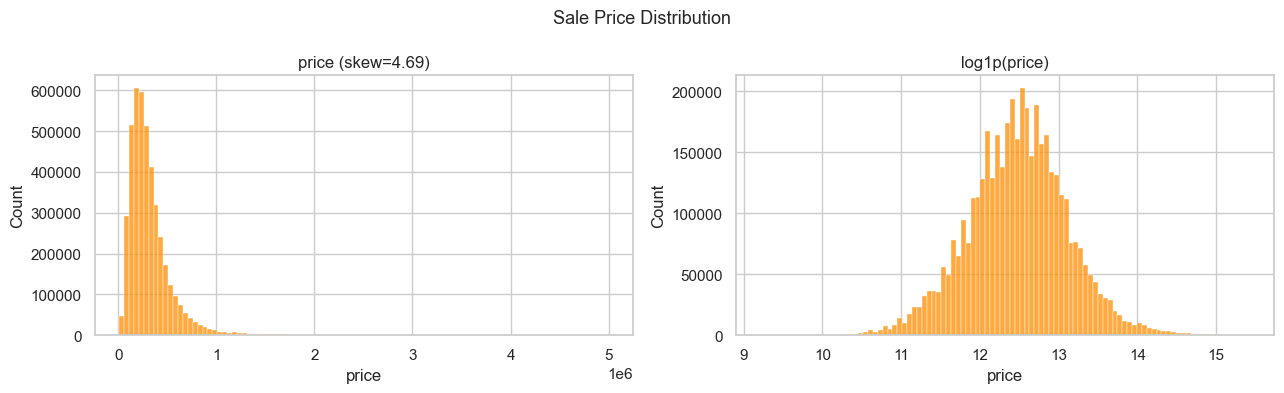

price skew         = 4.69
log1p(price) skew  = 0.04
count    4.291928e+06
mean     3.249459e+05
std      2.605594e+05
min      1.000000e+04
25%      1.750000e+05
50%      2.650000e+05
75%      3.950000e+05
max      5.000000e+06
Name: price, dtype: float64

Skewness (raw):  4.69
Skewness (log):  0.04
Median: £265,000   Mean: £324,946


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET], bins=100, ax=axes[0], color="darkorange")
axes[0].set_title(f"price (skew={df[TARGET].skew():.2f})")
sns.histplot(np.log1p(df[TARGET]), bins=100, ax=axes[1], color="darkorange")
axes[1].set_title("log1p(price)")
fig.suptitle("Sale Price Distribution", fontsize=13)
plt.tight_layout(); plt.show()

print(f"price skew         = {df[TARGET].skew():.2f}")
print(f"log1p(price) skew  = {np.log1p(df[TARGET]).skew():.2f}")
print(df[TARGET].describe())
print(f"\nSkewness (raw):  {df[TARGET].skew():.2f}")
print(f"Skewness (log):  {np.log1p(df[TARGET]).skew():.2f}")
print(f"Median: £{df[TARGET].median():,.0f}   Mean: £{df[TARGET].mean():,.0f}")

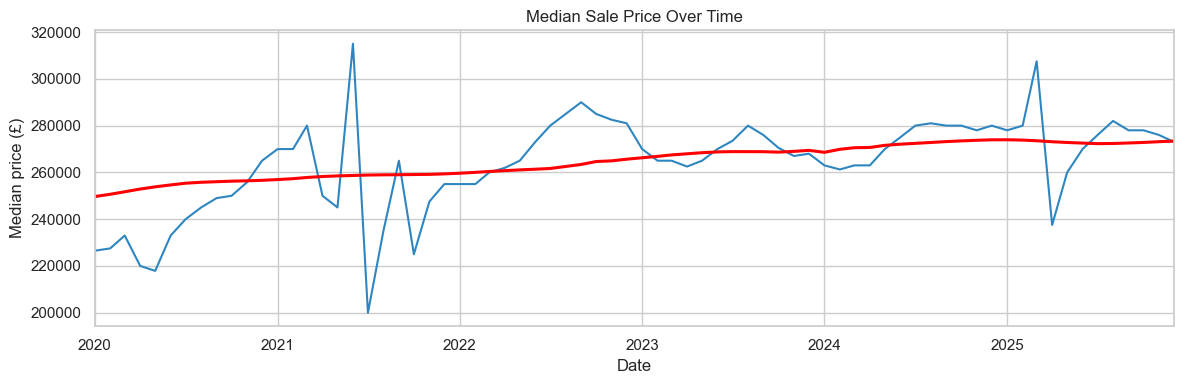

In [ ]:
# price over time 

monthly = df.groupby("ym")["price"].median()

# fit a straight line: price vs time-index
x = np.arange(len(monthly))
y = monthly.values
slope, intercept = np.polyfit(x, y, 1)
line = slope * x + intercept

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly.values, color="#B0C4DE", linewidth=0.9, label="Monthly median")
plt.plot(monthly.index, line, color="#E24B4A", linewidth=2.2, label="Linear trend")
plt.title("Median Sale Price Over Time")
plt.xlabel("Date"); plt.ylabel("Median price (£)")
plt.legend()
plt.tight_layout()
plt.savefig("graphs/price_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

# the numbers for your prose
print(f"Trend: £{slope:,.0f} per month  (£{slope*12:,.0f} per year)")
print(f"Start of line: £{line[0]:,.0f}   End of line: £{line[-1]:,.0f}")
print(f"Total rise over period: £{line[-1]-line[0]:,.0f} ({(line[-1]/line[0]-1)*100:.1f}%)")

## 2. Numerical distributions -> histogram + boxplot each


Skewness (|skew|>1 = strongly skewed):
comp1_distance_km            13.60
comp3_distance_km            12.27
comp2_distance_km            10.73
metro_within_1km              6.45
rail_within_5km               3.42
comp2_floor_area              3.03
comp1_floor_area              3.02
comp3_floor_area              2.97
total_floor_area              2.95
rail_within_1km               2.27
construction_year_exact       1.90
dist_primary_km               1.87
dist_secondary_km             1.26
dist_airport_km              -0.88
number_habitable_rooms        0.85
dist_rail_km                  0.79
current_energy_efficiency    -0.78
dist_metro_km                -0.67
exact_lat                     0.32
area_past_price               0.26
dist_coast_km                -0.25
construction_year            -0.23
property_age                  0.23
comp1_days_ago                0.13
sale_time                     0.11
comp2_days_ago                0.11
exact_lon                    -0.11
comp3_days_ago  

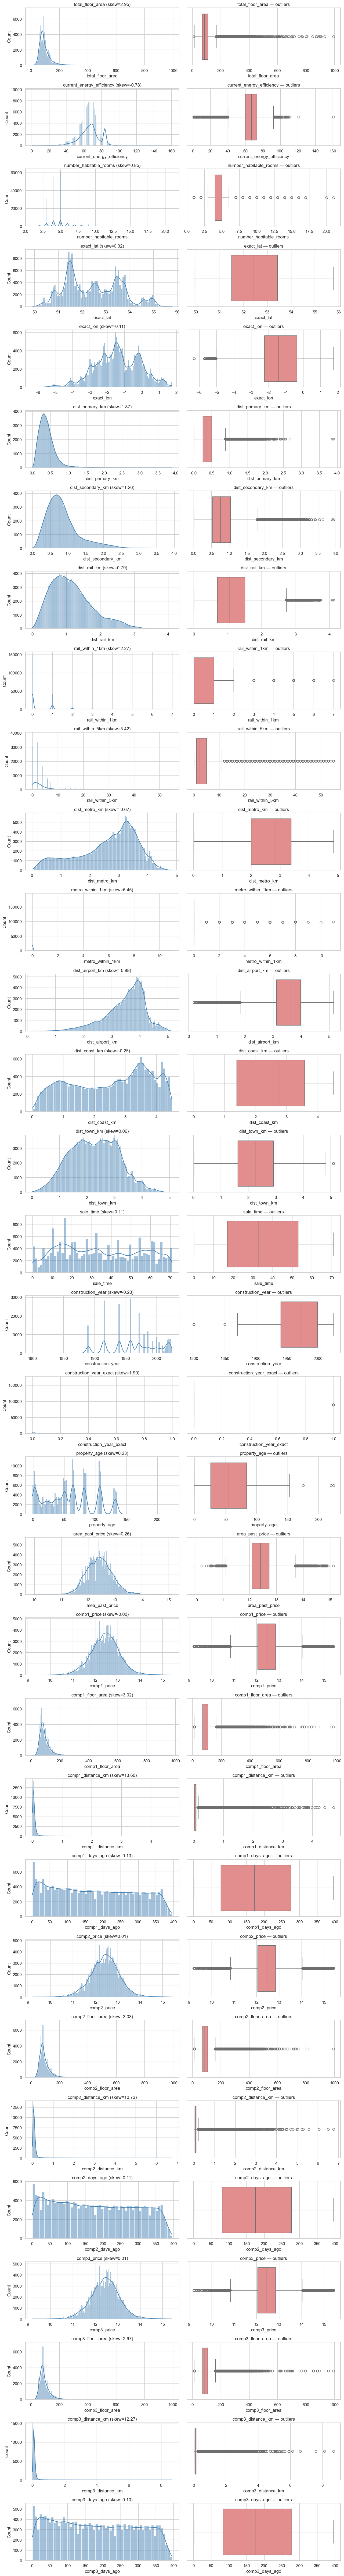

In [ ]:
skews = df[numerical].skew().sort_values(key=abs, ascending=False)
print("Skewness (|skew|>1 = strongly skewed):")
print(skews.round(2).to_string())

n = len(numerical)
fig, axes = plt.subplots(n, 2, figsize=(13, 3 * n))
for i, col in enumerate(numerical):
    sns.histplot(SAMPLE[col], kde=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"{col} (skew={df[col].skew():.2f})")
    sns.boxplot(x=SAMPLE[col], ax=axes[i, 1], color="lightcoral")
    axes[i, 1].set_title(f"{col} — outliers")
plt.tight_layout(); plt.show()

## 2. Categorical counts

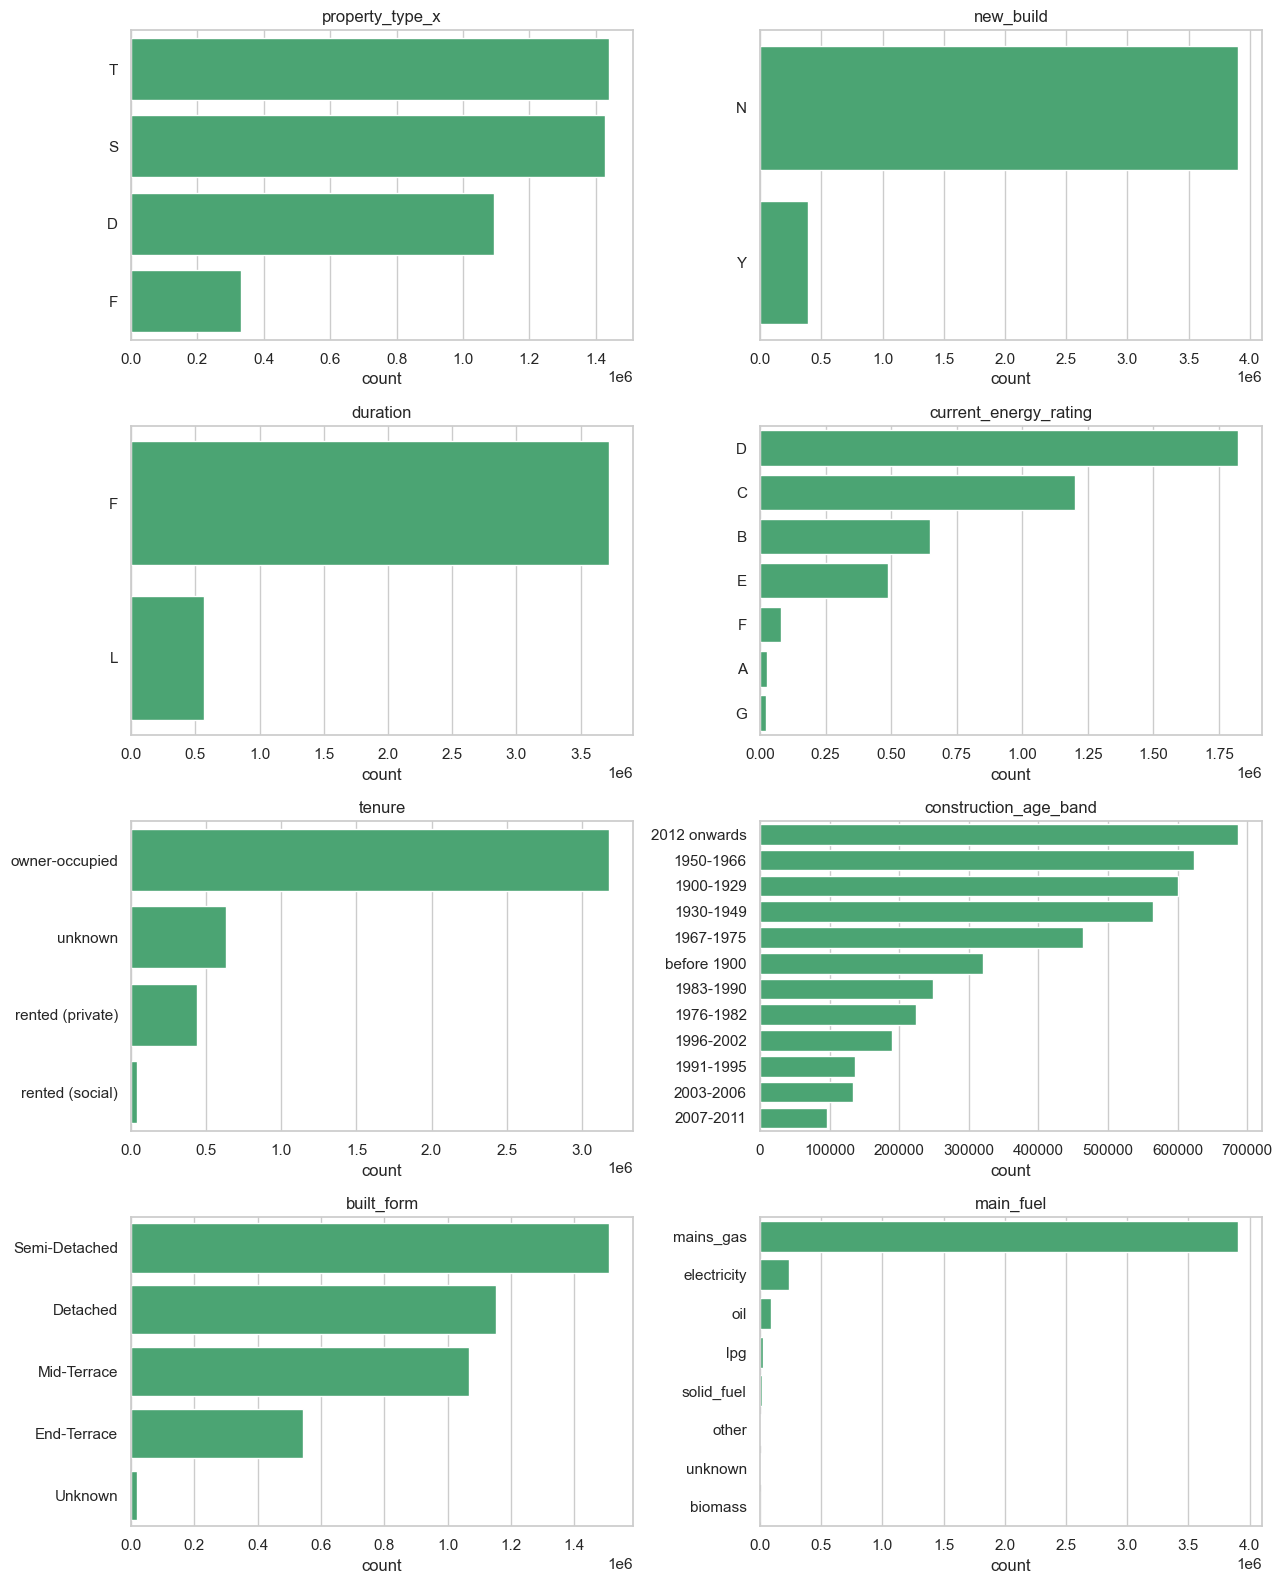

In [ ]:
n = len(categorical)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(categorical):
    order = df[col].value_counts().index
    sns.countplot(y=df[col].astype(str), order=order.astype(str),
                  ax=axes[i], color="mediumseagreen")
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel("")
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## 3. Numerical -> price


                           pearson  spearman    gap
feature                                            
comp1_price                  0.678     0.804  0.126
comp2_price                  0.640     0.755  0.115
comp3_price                  0.620     0.729  0.109
area_past_price              0.632     0.720  0.088
total_floor_area             0.626     0.571 -0.055
exact_lat                   -0.347    -0.482 -0.135
number_habitable_rooms       0.483     0.478 -0.006
comp1_floor_area             0.383     0.351 -0.031
exact_lon                    0.249     0.332  0.083
comp2_floor_area             0.327     0.293 -0.034
comp3_floor_area             0.299     0.263 -0.035
dist_town_km                 0.088     0.152  0.065
dist_metro_km               -0.209    -0.145  0.064
dist_airport_km             -0.069    -0.143 -0.074
comp2_distance_km            0.102     0.142  0.040
comp3_distance_km            0.101     0.141  0.041
comp1_distance_km            0.098     0.140  0.041
dist_primary

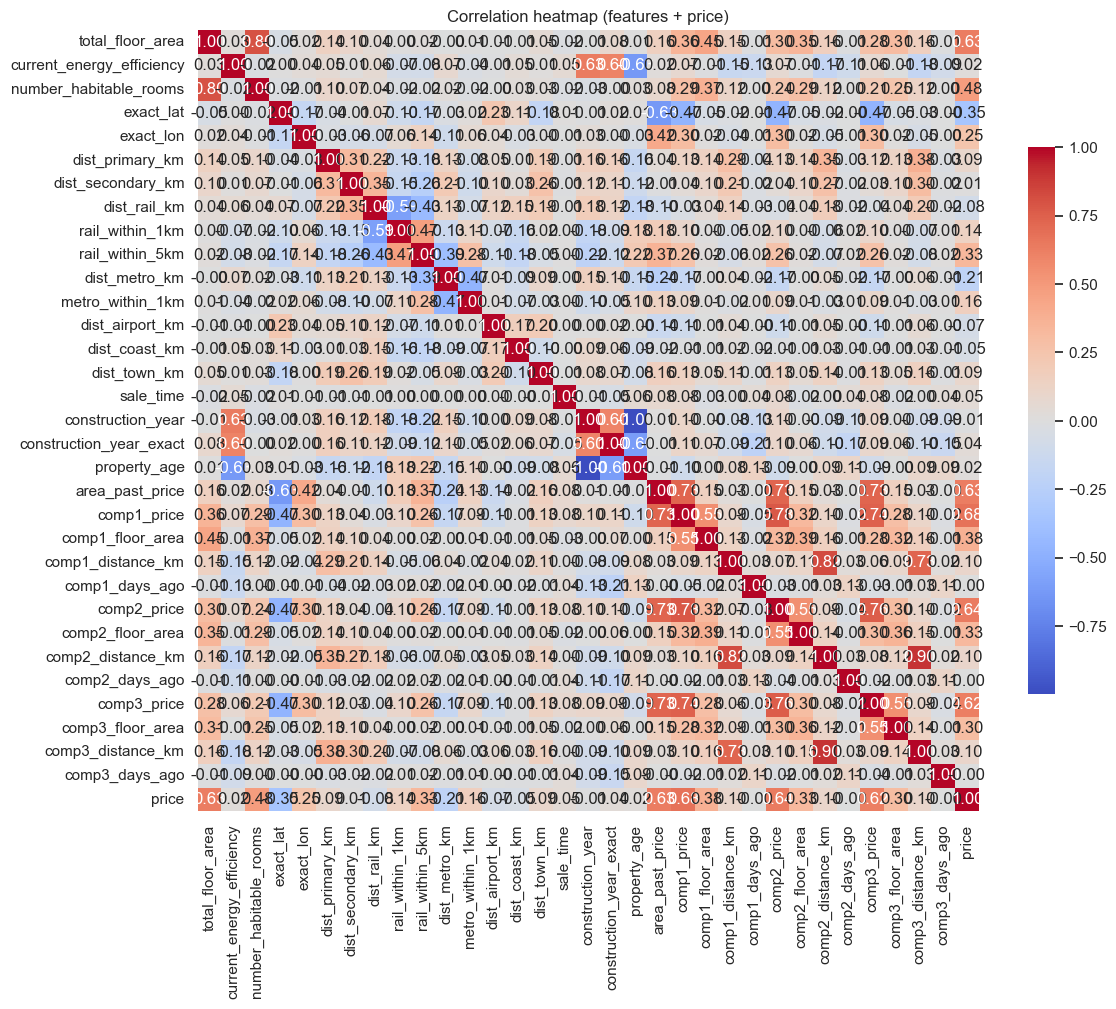

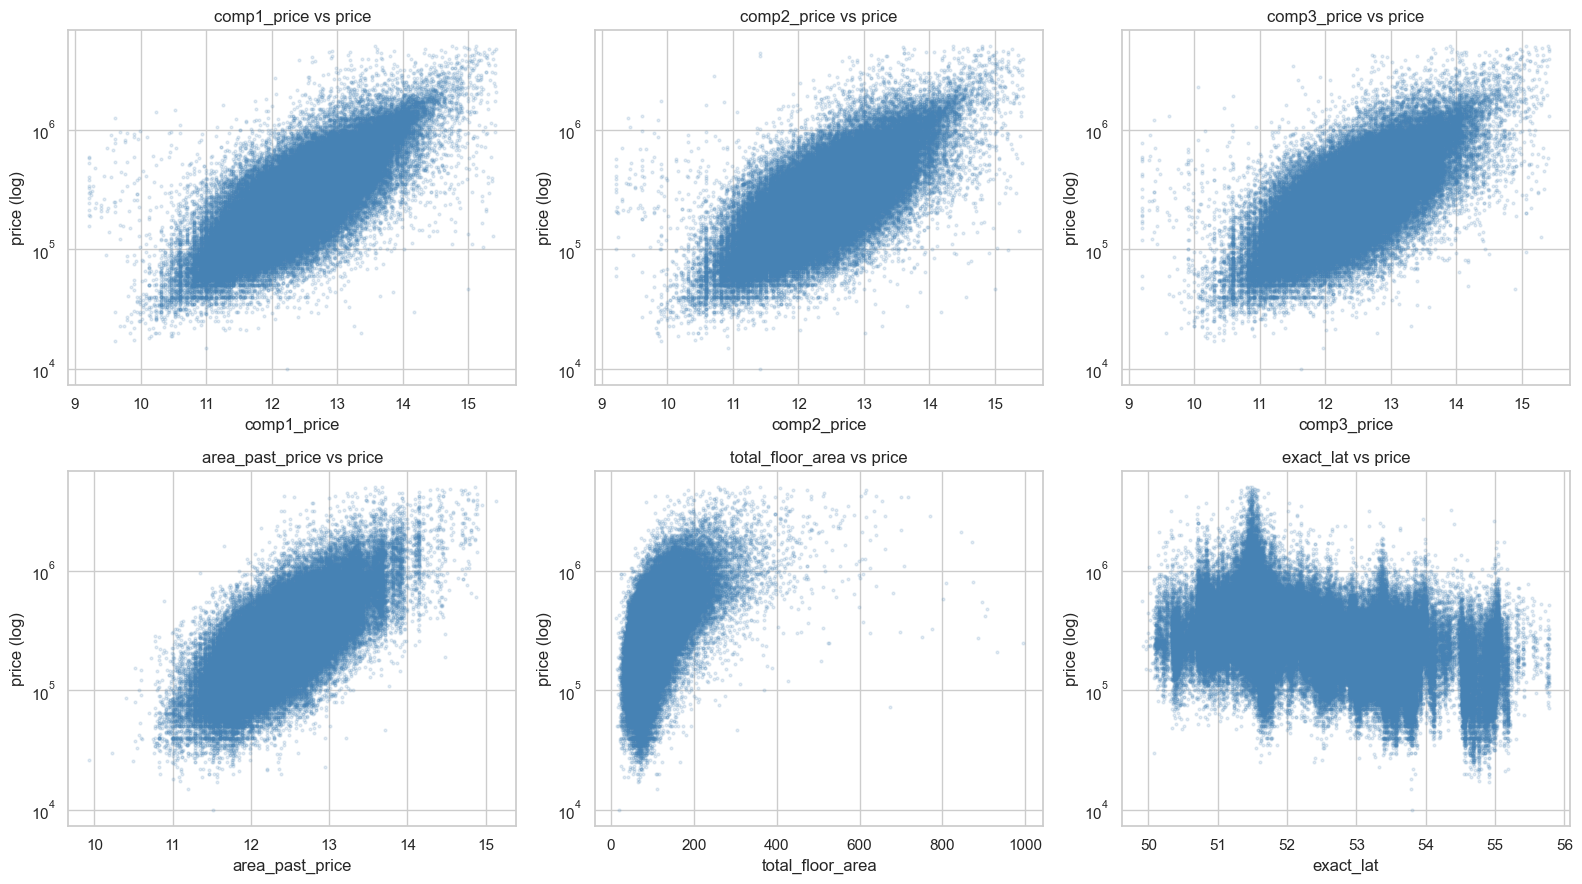

In [ ]:
rows = []
for col in numerical:
    sub = df[[col, TARGET]].dropna()
    rows.append({
        "feature": col,
        "pearson":  sub[col].corr(sub[TARGET], method="pearson"),
        "spearman": sub[col].corr(sub[TARGET], method="spearman"),
    })
corr_tbl = (pd.DataFrame(rows).set_index("feature")
            .assign(gap=lambda d: (d.spearman - d.pearson))
            .sort_values("spearman", key=abs, ascending=False))
print(corr_tbl.round(3).to_string())

# heatmap among numerics + price (spot multicollinearity)
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical + [TARGET]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .7})
plt.title("Correlation heatmap (features + price)")
plt.tight_layout(); plt.show()

# scatter of top features vs price (on sample, log-y since price is skewed)
top = corr_tbl.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.reshape(-1)
for i, col in enumerate(top):
    axes[i].scatter(SAMPLE[col], SAMPLE[TARGET], s=4, alpha=0.15, color="steelblue")
    axes[i].set_yscale("log")
    axes[i].set_title(f"{col} vs price")
    axes[i].set_xlabel(col); axes[i].set_ylabel("price (log)")
plt.tight_layout(); plt.show()

## 3. Categorical -> price


Correlation ratio to price (higher = stronger):
                       eta (0-1)
feature                         
property_type_x            0.294
built_form                 0.277
duration                   0.144
tenure                     0.098
main_fuel                  0.095
construction_age_band      0.092
current_energy_rating      0.050
new_build                  0.029


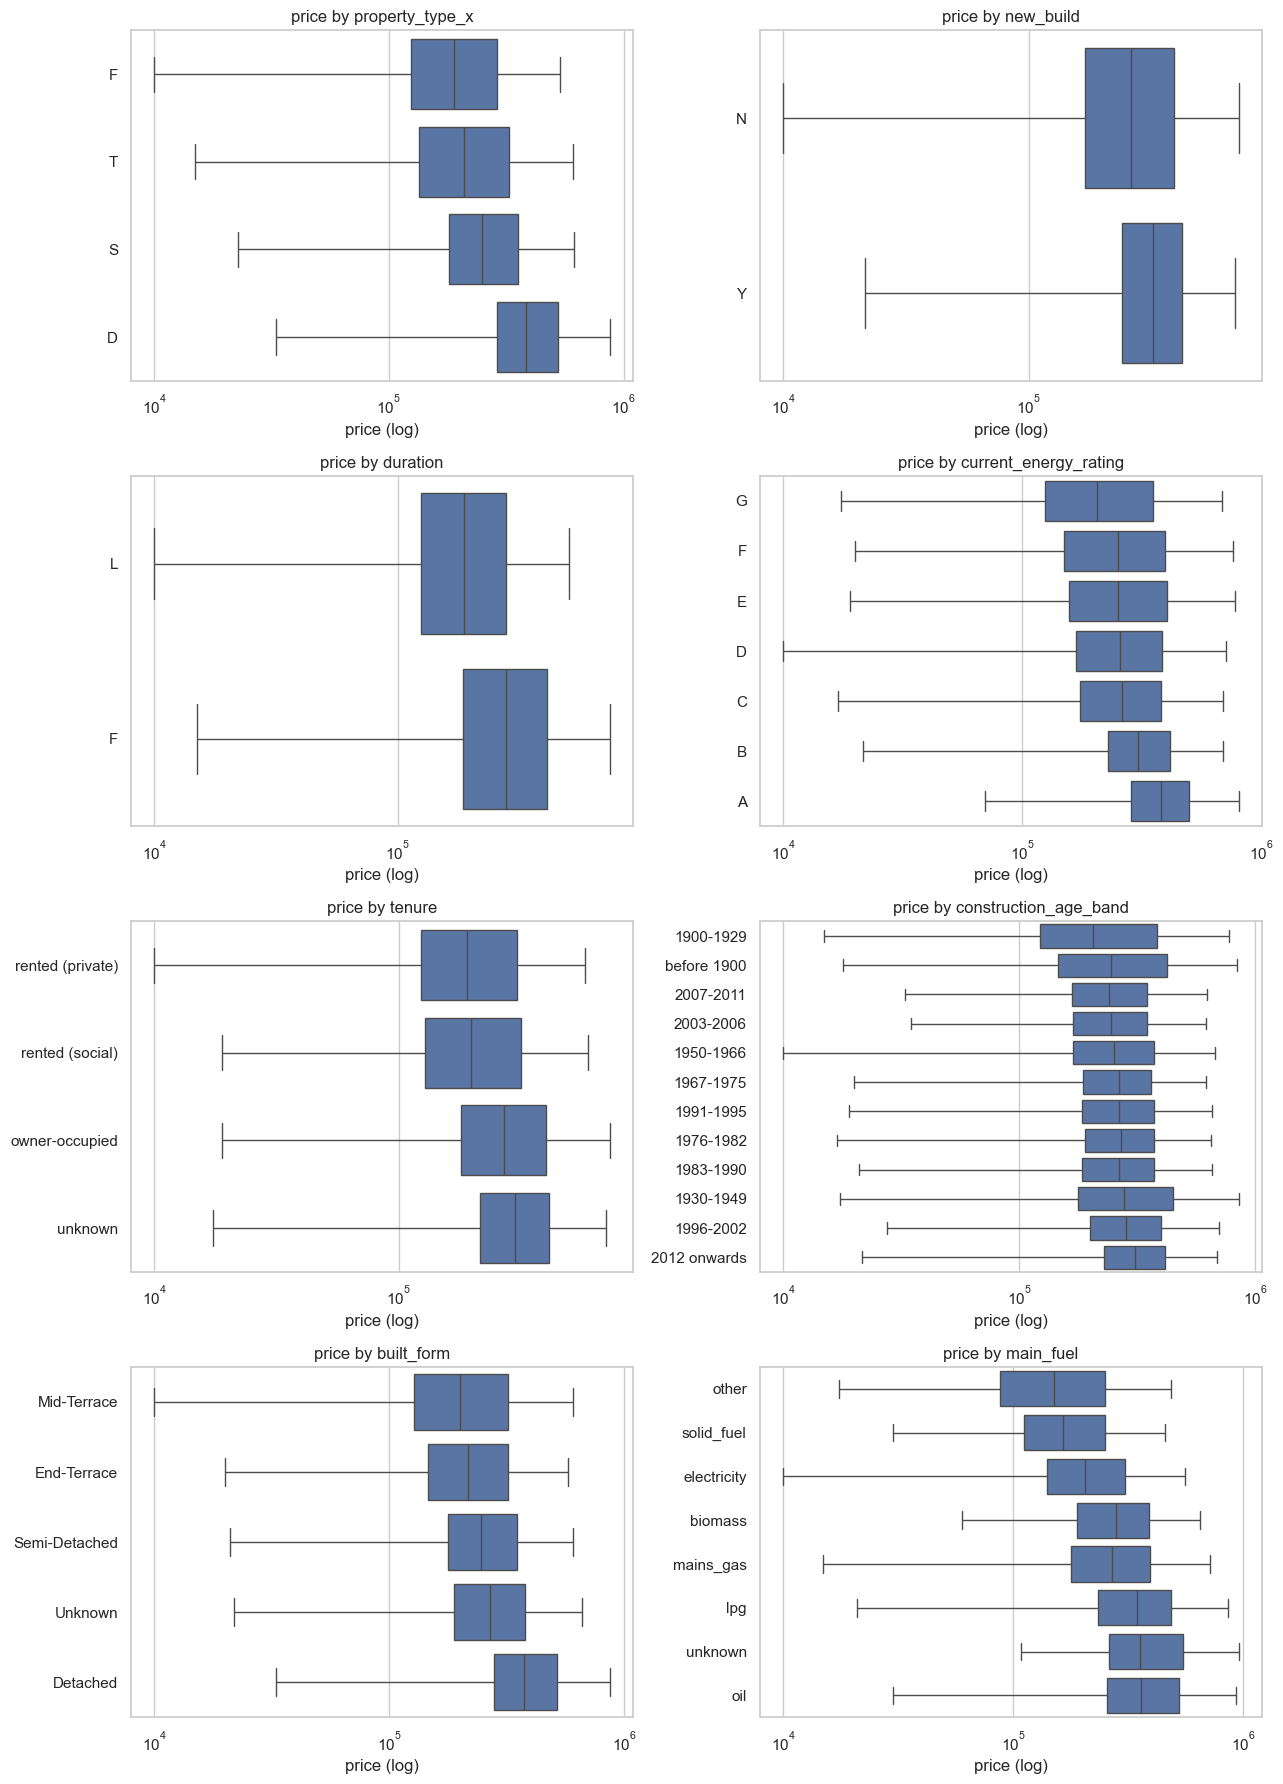

In [ ]:
def correlation_ratio(cats, values):
    d = pd.DataFrame({"c": cats, "v": values}).dropna()
    gm = d["v"].mean()
    ss_between = d.groupby("c")["v"].apply(lambda g: len(g) * (g.mean() - gm) ** 2).sum()
    ss_total = ((d["v"] - gm) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total else np.nan

eta_rows = [{"feature": c, "eta (0-1)": correlation_ratio(df[c], df[TARGET])}
            for c in categorical]
eta_tbl = pd.DataFrame(eta_rows).set_index("feature").sort_values("eta (0-1)", ascending=False)
print("Correlation ratio to price (higher = stronger):")
print(eta_tbl.round(3).to_string())

n = len(categorical)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(categorical):
    order = df.groupby(col)[TARGET].median().sort_values().index
    sns.boxplot(x=SAMPLE[TARGET], y=SAMPLE[col].astype(str),
                order=order.astype(str), ax=axes[i], showfliers=False)
    axes[i].set_xscale("log")
    axes[i].set_title(f"price by {col}")
    axes[i].set_ylabel(""); axes[i].set_xlabel("price (log)")
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

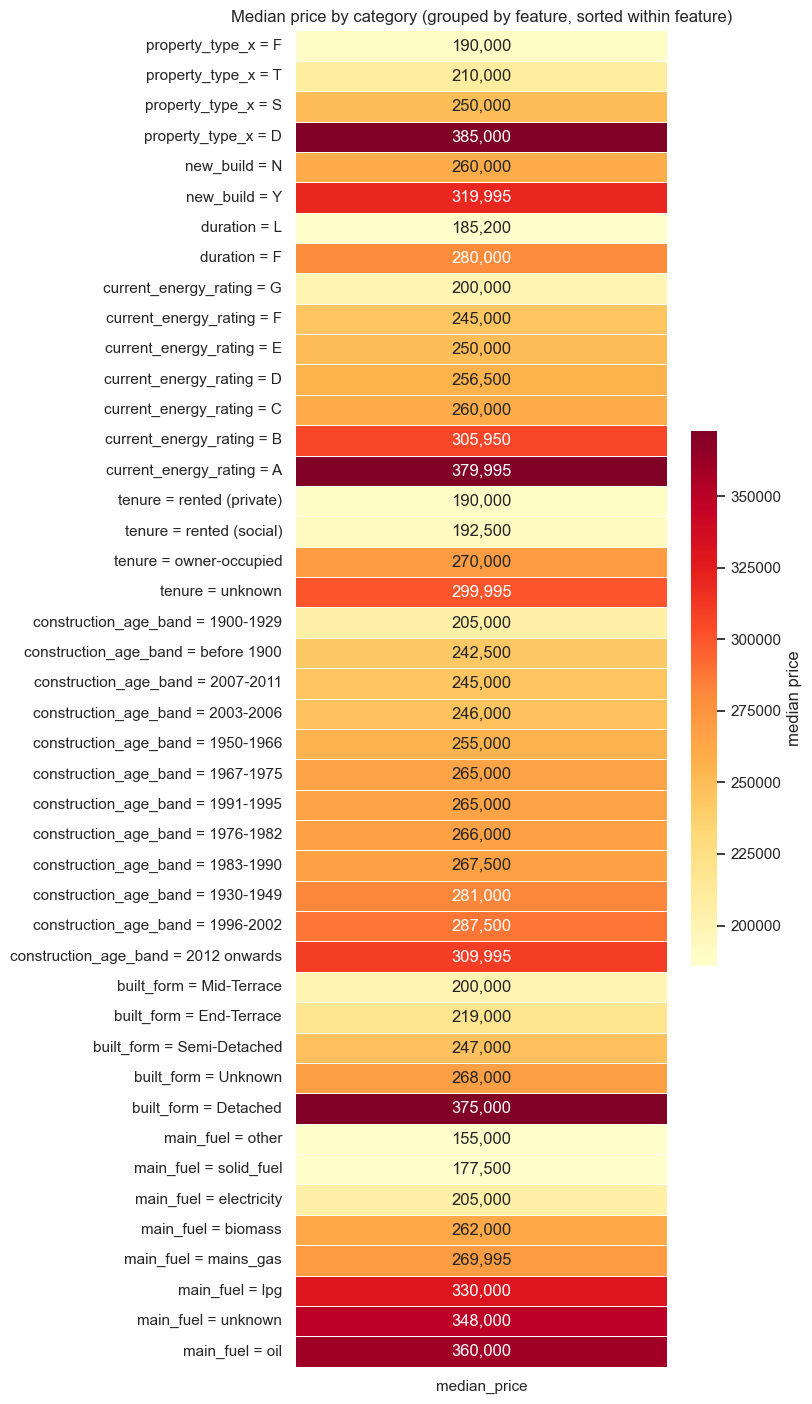

In [ ]:
# Median price by each category value — grouped by feature, sorted within feature
rows = []
for c in categorical:                                    # feature order = your categorical list
    med = df.groupby(c)[TARGET].median().sort_values()   # sort categories WITHIN the feature
    for val, price in med.items():
        rows.append({"category": f"{c} = {val}", "median_price": price})

hm = pd.DataFrame(rows).set_index("category")            # keep insertion order (no global sort)

# clip colour scale to 5th-95th percentile so a few extremes don't wash out the rest
vmin = hm["median_price"].quantile(0.05)
vmax = hm["median_price"].quantile(0.95)

plt.figure(figsize=(8, len(hm) * 0.3 + 1))               # wider figure -> column isn't a thin sliver
ax = sns.heatmap(
    hm, annot=True, fmt=",.0f", cmap="YlOrRd",
    vmin=vmin, vmax=vmax,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "median price", "shrink": 0.4},
)
ax.set_ylabel("")
plt.title("Median price by category (grouped by feature, sorted within feature)")
plt.tight_layout()
plt.show()

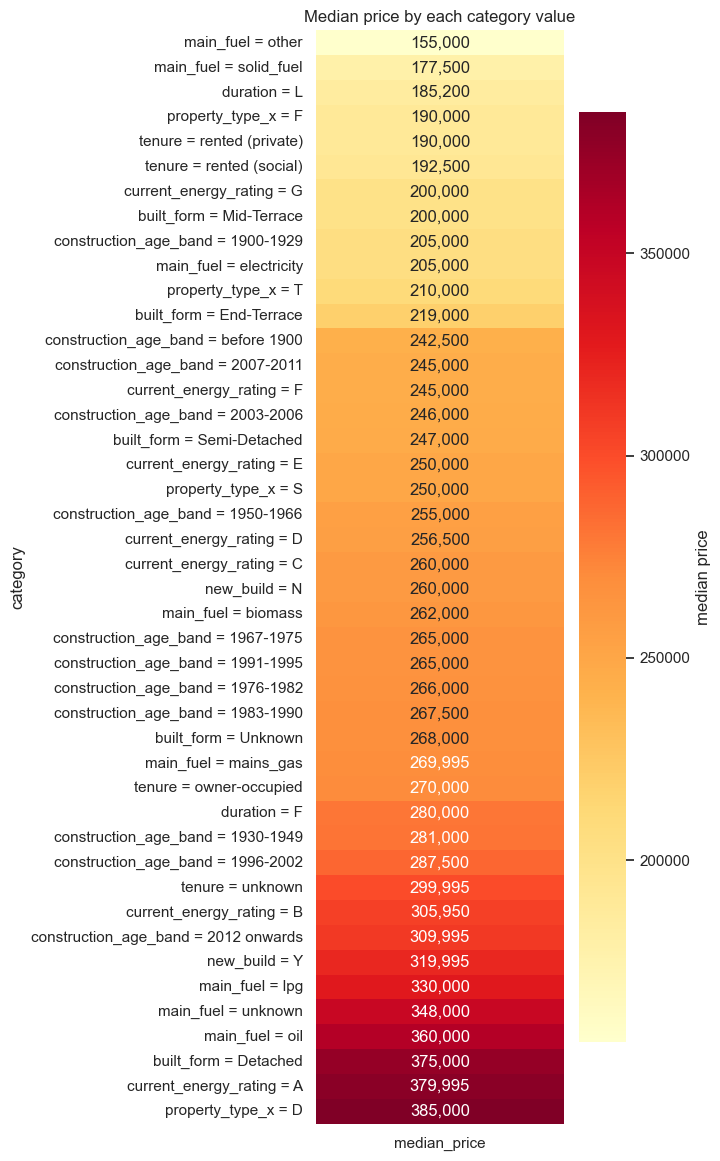

In [ ]:
rows = []
for c in categorical:
    med = df.groupby(c)[TARGET].median()
    for val, price in med.items():
        rows.append({"category": f"{c} = {val}", "median_price": price})

hm = pd.DataFrame(rows).set_index("category").sort_values("median_price")

plt.figure(figsize=(4, len(hm) * 0.3 + 1))
sns.heatmap(hm, annot=True, fmt=",.0f", cmap="YlOrRd",
            cbar_kws={"label": "median price"})
plt.title("Median price by each category value")
plt.tight_layout(); plt.show()